In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from run_config import REPO_PATH, SEASONS, PROCESSED_DATA_PATH, FEATURES_PATH
from experiment_config import TARGET_RANGES, TEST_SIZE, EXPERIMENT_NAME, KEY_COLUMNS

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *

In [2]:
features_path = f"{FEATURES_PATH}/all_combined_features.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(SEASONS)
target_dfs=[pd.read_csv(f"{PROCESSED_DATA_PATH}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=KEY_COLUMNS).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, KEY_COLUMNS)

In [13]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 32), (64, 32, 32)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001, 0.1],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_iter': [1000],
}

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'gamma': [0, 1]
}


In [6]:
feature_df.fillna(-1, inplace=True)

In [ ]:
run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TARGET_RANGES,
    model_wrapper_class=lambda **params: SklearnWrapper(MLPClassifier, **params),
    model_param_grid=mlp_param_grid,
    test_size=TEST_SIZE,
    k=5,
    experiment_name=EXPERIMENT_NAME,
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPClassifier',
    key_columns=KEY_COLUMNS,
)



Fold 1 training size: 679 (50.0% of data)

--- Fold 1 | Training for target: home_goals ---

--- Fold 1 | Training for target: away_goals ---

Fold 2 training size: 815 (60.0% of data)

--- Fold 2 | Training for target: home_goals ---

--- Fold 2 | Training for target: away_goals ---

Fold 3 training size: 951 (70.0% of data)

--- Fold 3 | Training for target: home_goals ---

--- Fold 3 | Training for target: away_goals ---

Fold 4 training size: 1087 (80.0% of data)

--- Fold 4 | Training for target: home_goals ---

--- Fold 4 | Training for target: away_goals ---


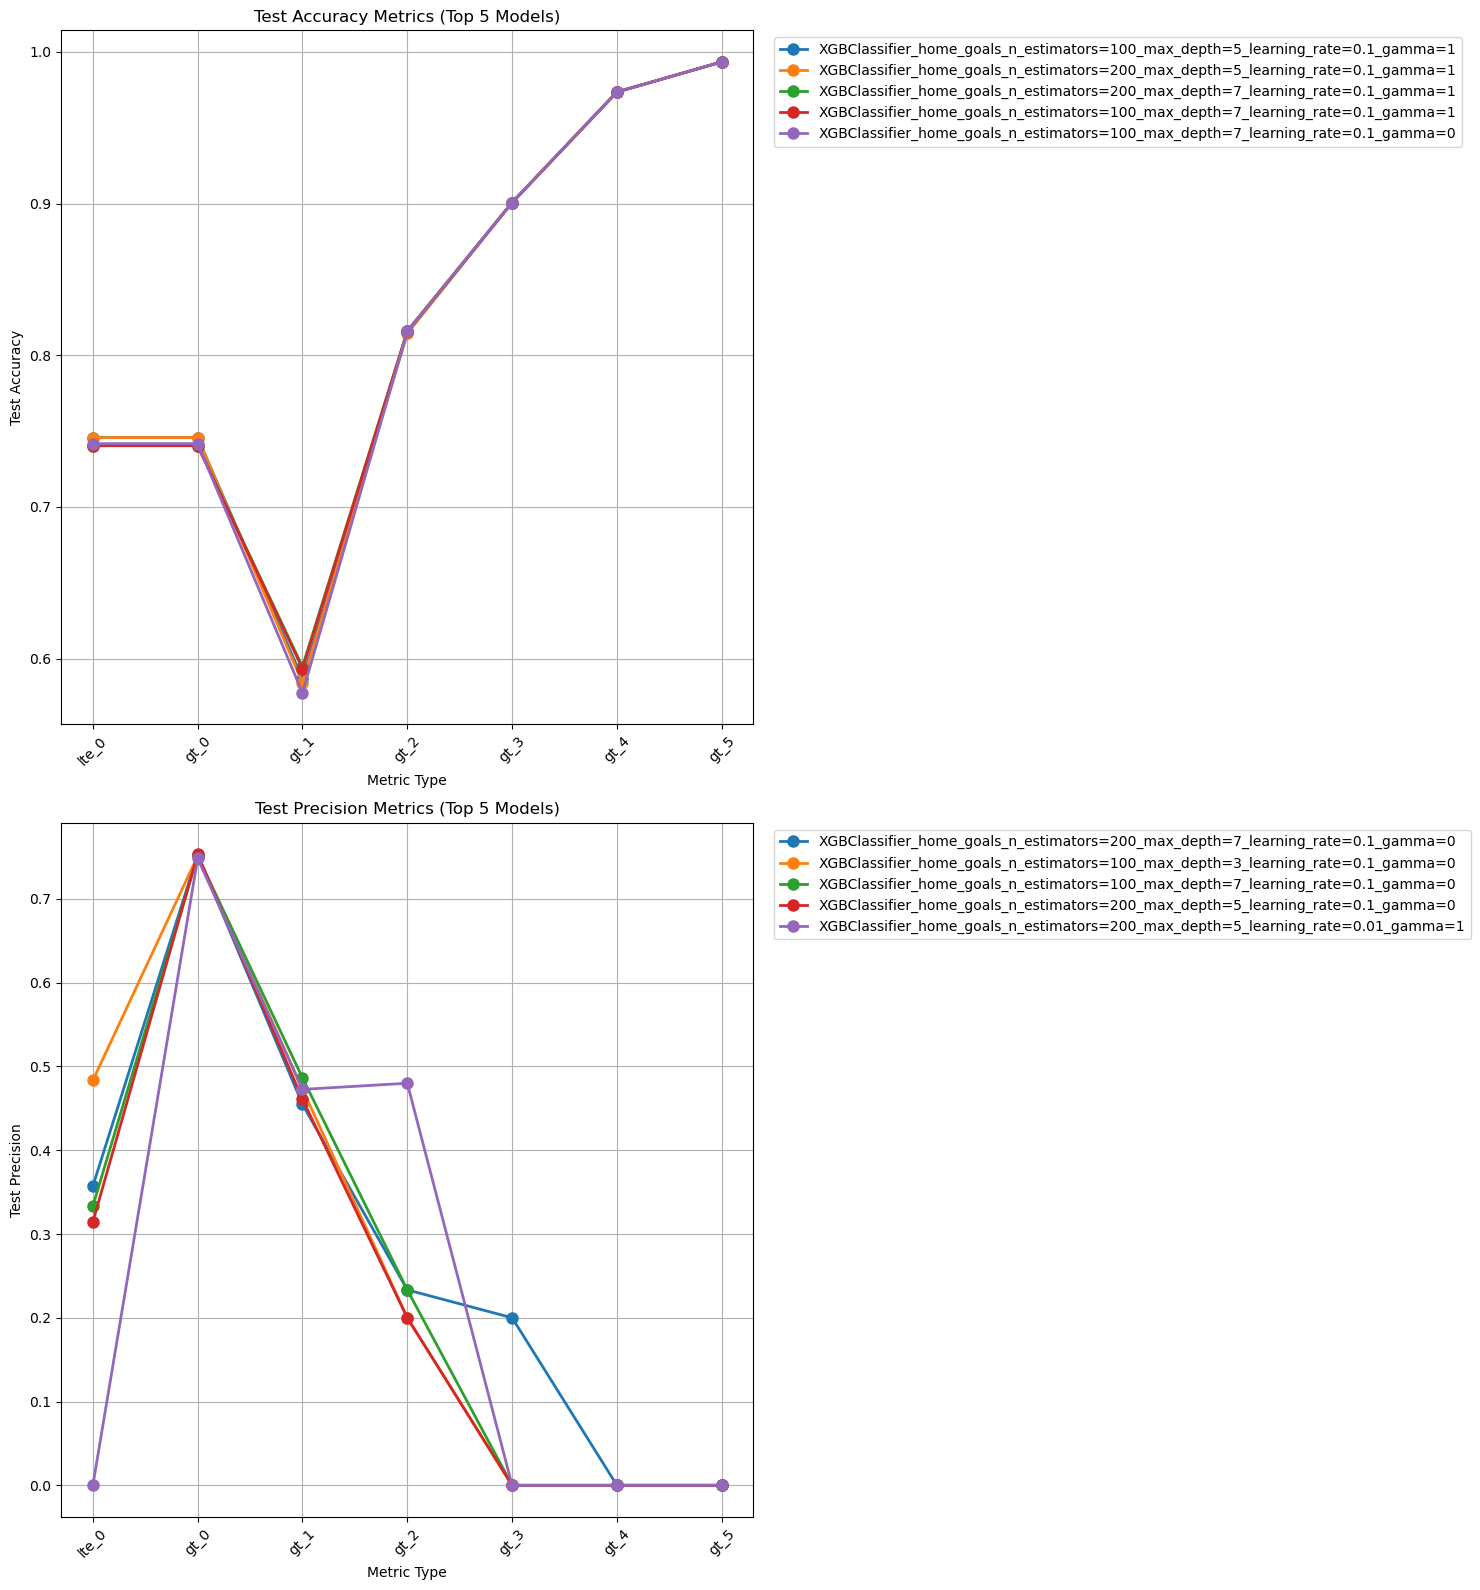

In [11]:
plot_metrics_for_target_and_model(
    experiment_name=EXPERIMENT_NAME,
    target_col="home_goals",
    model_name="XGBClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

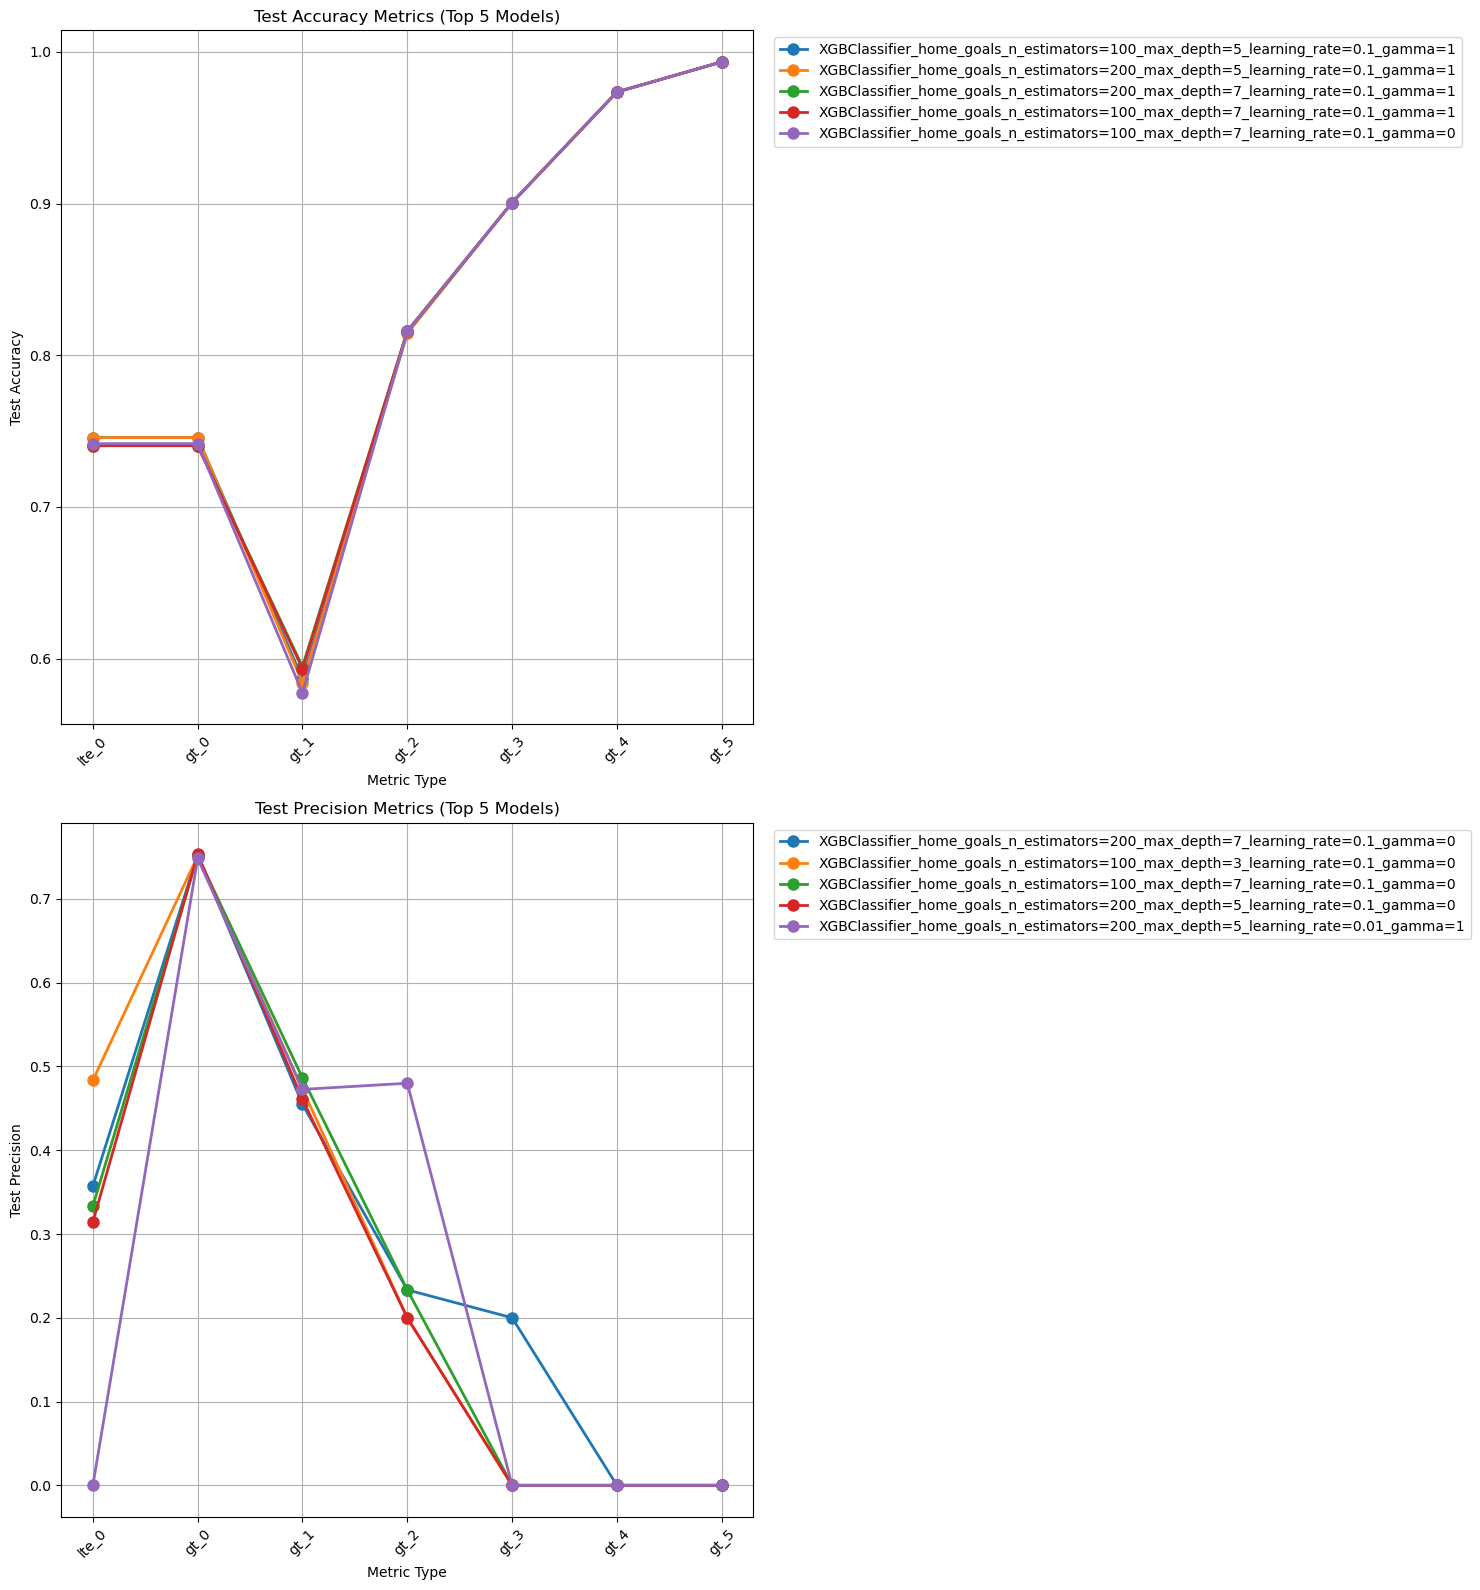

In [9]:
plot_metrics_for_target_and_model(
    experiment_name=EXPERIMENT_NAME,
    target_col="home_goals",
    model_name="XGBClassifier",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

[('metrics.home_goals_train_lte_0_accuracy', 0.8657479364383998)] [('metrics.home_goals_train_gt_0_accuracy', 0.8657479364383998), ('metrics.home_goals_train_gt_1_accuracy', 0.9797506403598449), ('metrics.home_goals_train_gt_2_accuracy', 0.9902550897583791), ('metrics.home_goals_train_gt_3_accuracy', 0.9818195382523699), ('metrics.home_goals_train_gt_4_accuracy', 0.9856109170632605), ('metrics.home_goals_train_gt_5_accuracy', 0.9910889763041648)]
['lte_0', 'gt_0', 'gt_1', 'gt_2', 'gt_3', 'gt_4', 'gt_5']
[('metrics.home_goals_train_lte_0_precision', 1.0)] [('metrics.home_goals_train_gt_0_precision', 0.8526211782498935), ('metrics.home_goals_train_gt_1_precision', 0.9561889394603336), ('metrics.home_goals_train_gt_2_precision', 1.0), ('metrics.home_goals_train_gt_3_precision', 1.0), ('metrics.home_goals_train_gt_4_precision', 1.0), ('metrics.home_goals_train_gt_5_precision', 1.0)]
['lte_0', 'gt_0', 'gt_1', 'gt_2', 'gt_3', 'gt_4', 'gt_5']


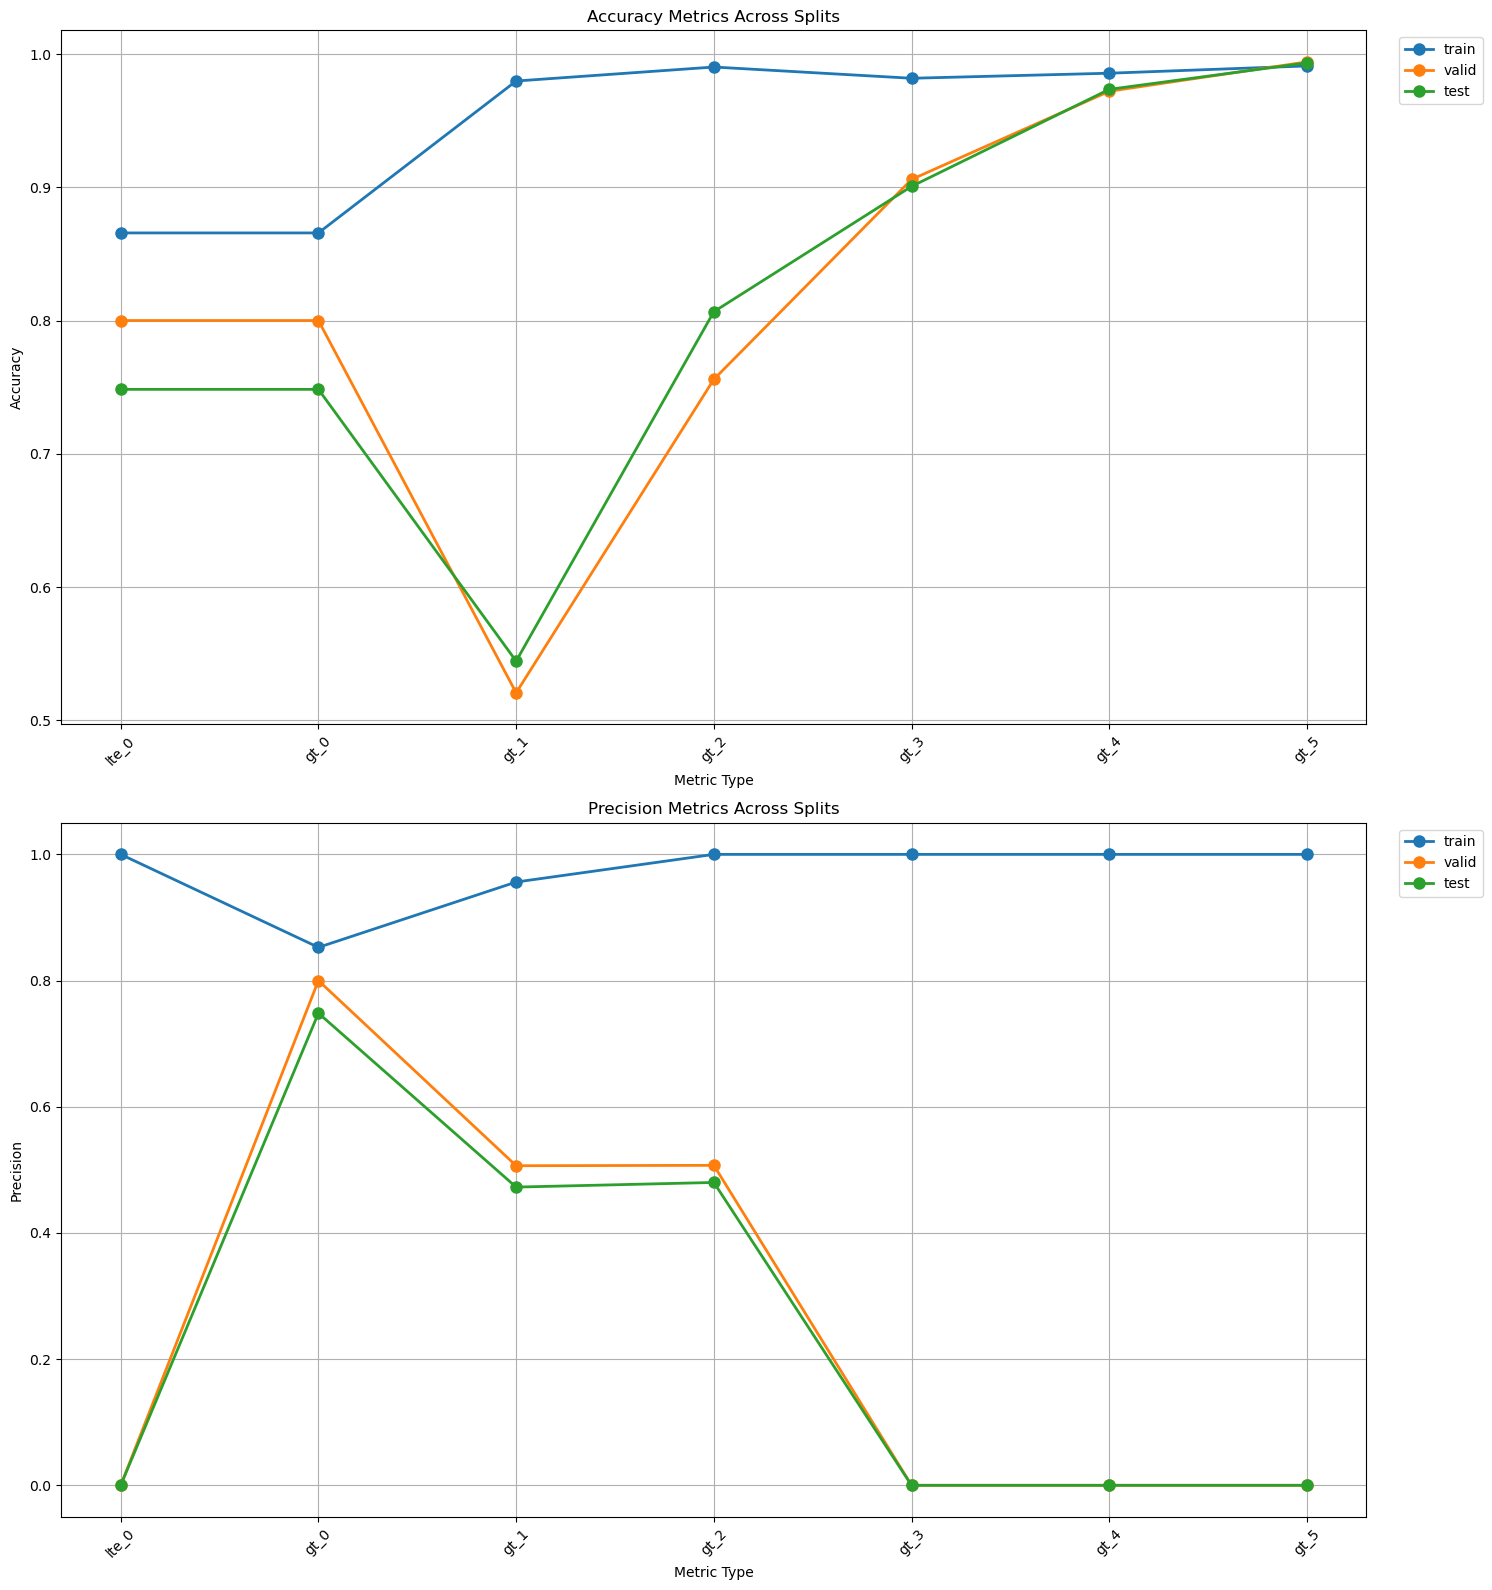

In [12]:
plot_run_metrics_by_split(experiment_name=EXPERIMENT_NAME,
                         run_name="XGBClassifier_home_goals_n_estimators=200_max_depth=5_learning_rate=0.01_gamma=1",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")